In [1]:
import pandas as pd
import numpy as np

data = pd.read_excel("../data/Datos_maestro_sensores.xlsx")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28654 entries, 0 to 28653
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sensor_periodo  28654 non-null  str           
 1   datetime        28654 non-null  datetime64[us]
 2   CO2_ppm         28654 non-null  float64       
 3   TVOC_ppb        28654 non-null  float64       
 4   AQI             28654 non-null  int64         
 5   CO_ppm          28654 non-null  float64       
 6   SO2_ppm         28654 non-null  float64       
 7   O3_ppm          28654 non-null  float64       
 8   NO2_ppm         28654 non-null  float64       
 9   PM2_5_ugm3      28654 non-null  int64         
 10  PM10_ugm3       28654 non-null  int64         
 11  temp_C          28654 non-null  float64       
 12  hum_pct         28654 non-null  float64       
 13  Bat_pct         28654 non-null  float64       
dtypes: datetime64[us](1), float64(9), int64(3), str(1)
memory usage: 

In [2]:
data.head()

,sensor_periodo,datetime,CO2_ppm,TVOC_ppb,AQI,CO_ppm,SO2_ppm,O3_ppm,NO2_ppm,PM2_5_ugm3,PM10_ugm3,temp_C,hum_pct,Bat_pct
0,D_P1,2025-11-06 20:09:35,1471.21,3722.70,5,1.225555,0.020990,0.008659,0.010098,22,26,21.9,33.3,57.8
1,D_P1,2025-11-06 20:10:18,1355.02,2765.60,5,1.126044,0.022898,0.011206,0.013286,21,24,21.8,33.4,57.5
2,D_P1,2025-11-06 20:11:19,1219.80,2015.61,4,1.073670,0.022898,0.010188,0.011161,21,25,21.7,33.2,57.6
3,D_P1,2025-11-06 20:12:19,1131.86,1576.97,4,1.087637,0.022135,0.010697,0.011692,20,23,21.7,33.6,57.7
4,D_P1,2025-11-06 20:13:20,1072.33,1301.72,4,1.042246,0.022517,0.009678,0.011692,20,22,21.4,33.5,57.8


In [3]:
data.describe()

,datetime,CO2_ppm,TVOC_ppb,AQI,CO_ppm,SO2_ppm,O3_ppm,NO2_ppm,PM2_5_ugm3,PM10_ugm3,temp_C,hum_pct,Bat_pct
count,28654,28654.000000,28654.000000,28654.000000,28654.000000,28654.000000,28654.000000,28654.000000,28654.000000,28654.000000,28654.000000,28654.000000,28654.000000
mean,2025-11-17 06:58:05.446324,678.419387,320.686568,2.160780,0.597857,0.014657,0.011844,0.016747,13.687199,14.779786,24.338085,43.406038,71.448765
min,2025-11-06 20:09:35,400.000000,0.000000,1.000000,0.200768,0.001145,0.000509,0.000531,1.000000,1.000000,1.400000,0.000000,0.000000
25%,2025-11-14 15:35:38.500000,521.592500,85.102500,2.000000,0.333449,0.005343,0.006622,0.011161,6.000000,6.000000,19.700000,36.000000,73.800000
50%,2025-11-17 18:04:17,621.195000,147.605000,2.000000,0.410264,0.010304,0.010697,0.015412,10.000000,11.000000,23.900000,43.400000,74.600000
75%,2025-11-21 22:28:42.250000,758.547500,260.500000,3.000000,0.559531,0.022135,0.015791,0.021258,17.000000,19.000000,26.900000,51.400000,76.100000
max,2025-11-25 13:24:23,25979.920000,44927.890000,5.000000,8.729025,0.353015,0.500206,0.366175,544.000000,615.000000,61.600000,76.700000,81.400000
std,NaN,514.986212,1208.232759,0.854106,0.812953,0.013972,0.010407,0.011318,20.006985,18.189132,7.015055,12.728724,11.361171


In [4]:
num_cols = data.select_dtypes(include=[np.number]).columns

cat_cols = data.select_dtypes(exclude=[np.number]).columns

print("Numéricas:", num_cols)
print("No numéricas:", cat_cols)

Numéricas: Index(['CO2_ppm', 'TVOC_ppb', 'AQI', 'CO_ppm', 'SO2_ppm', 'O3_ppm', 'NO2_ppm',
       'PM2_5_ugm3', 'PM10_ugm3', 'temp_C', 'hum_pct', 'Bat_pct'],
      dtype='str')
No numéricas: Index(['sensor_periodo', 'datetime'], dtype='str')


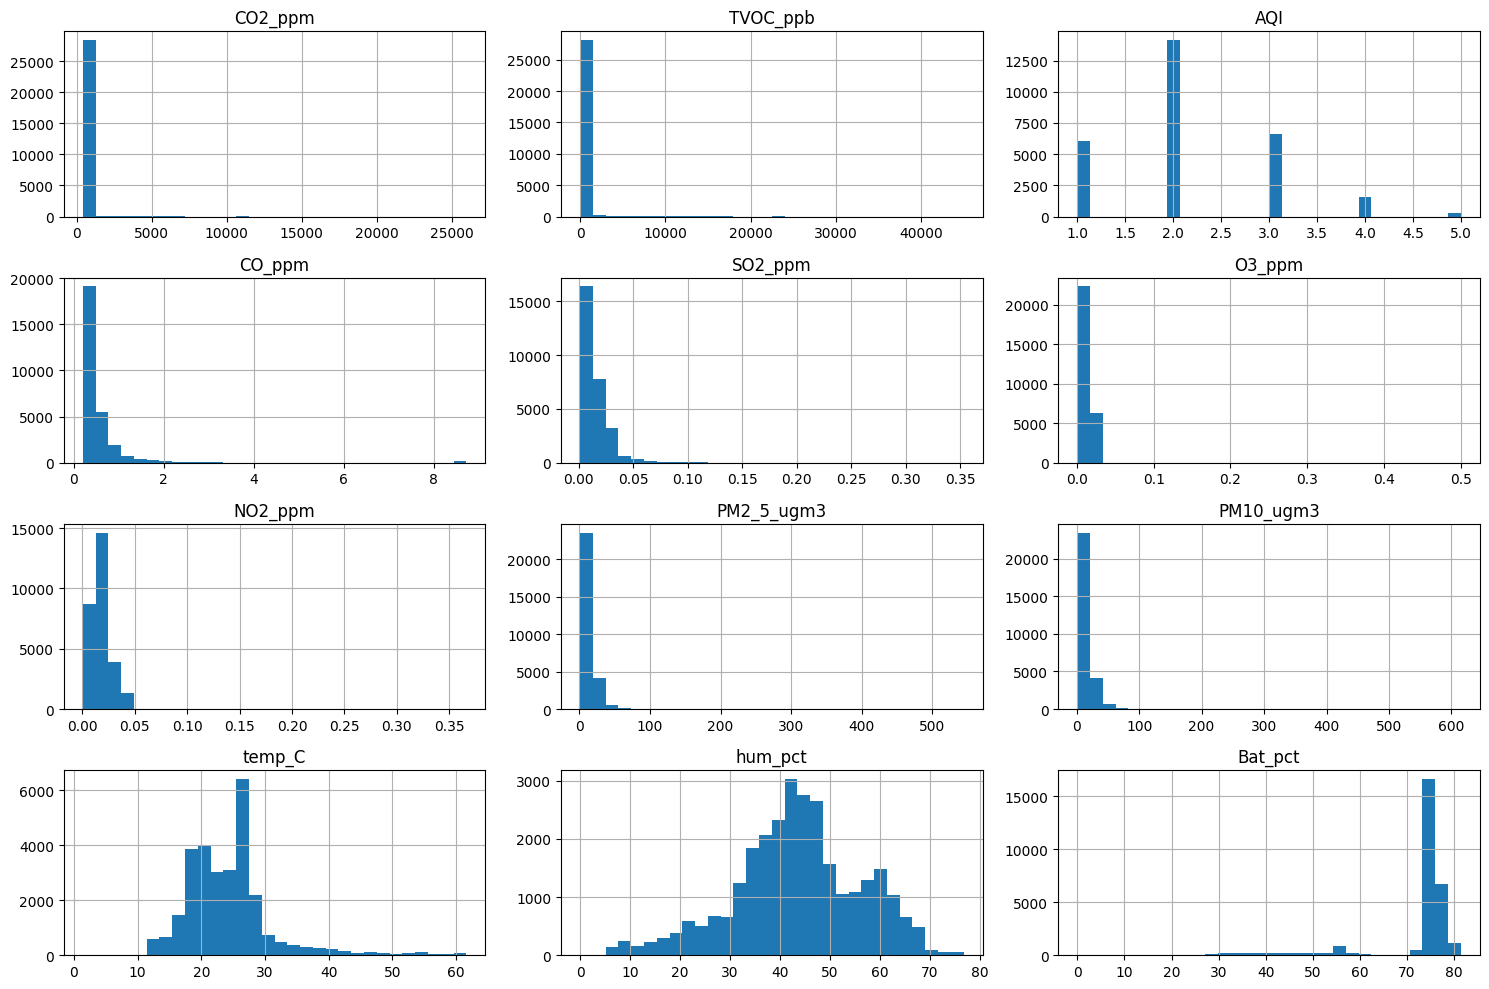

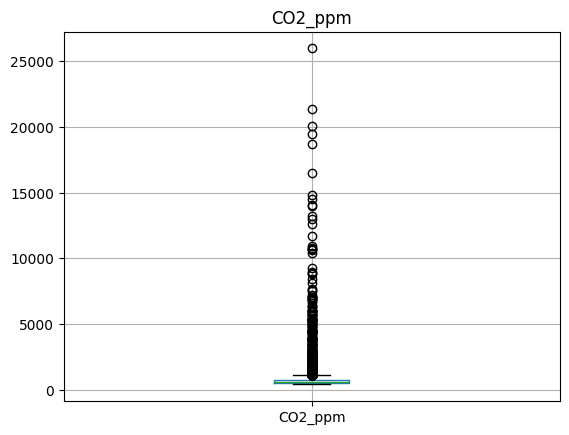

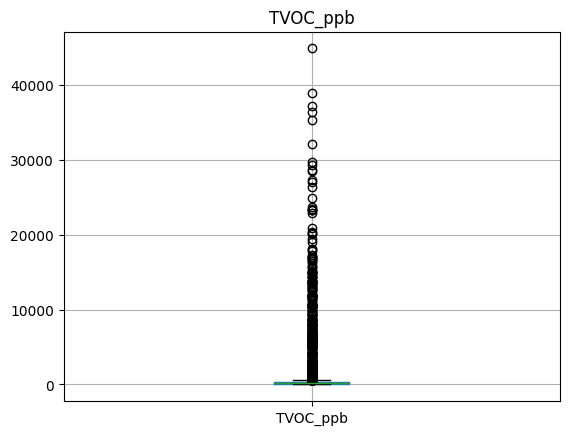

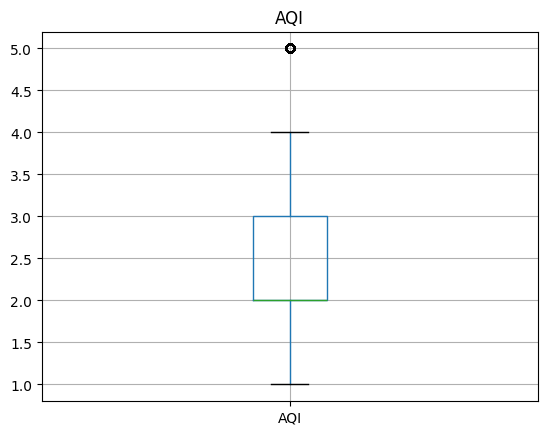

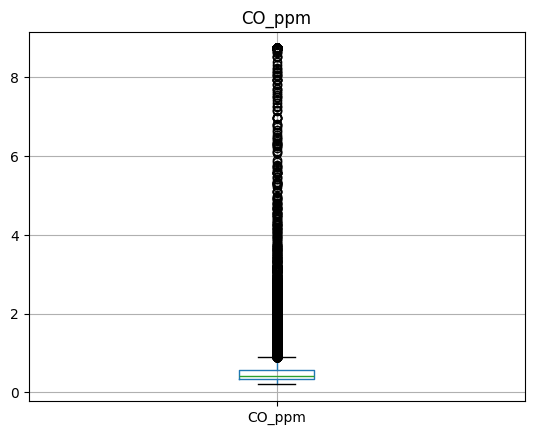

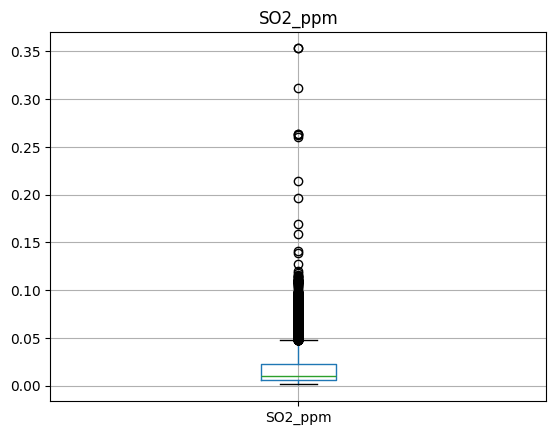

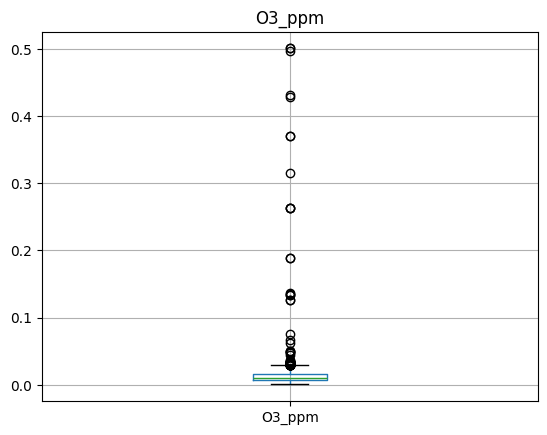

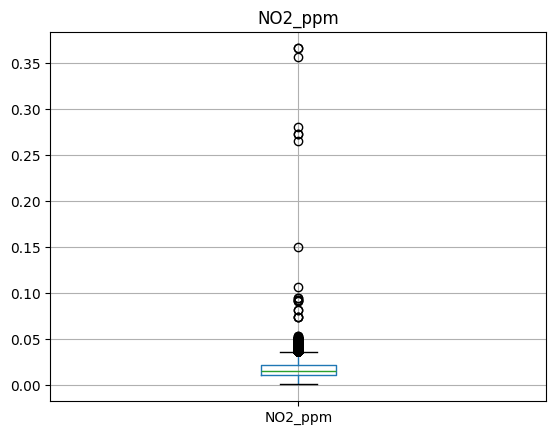

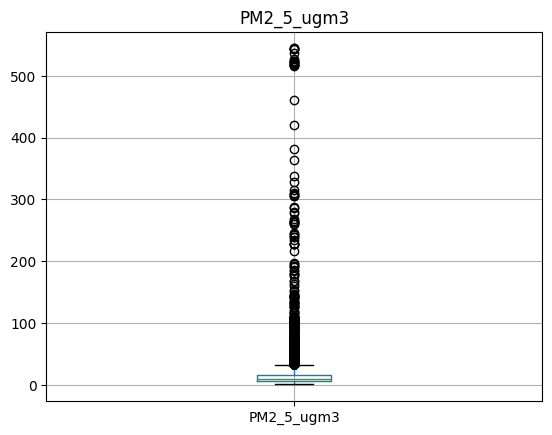

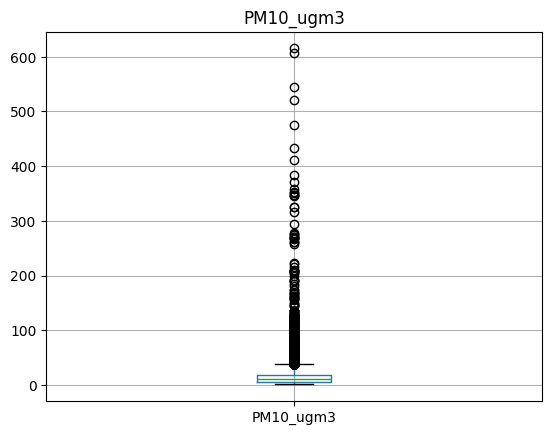

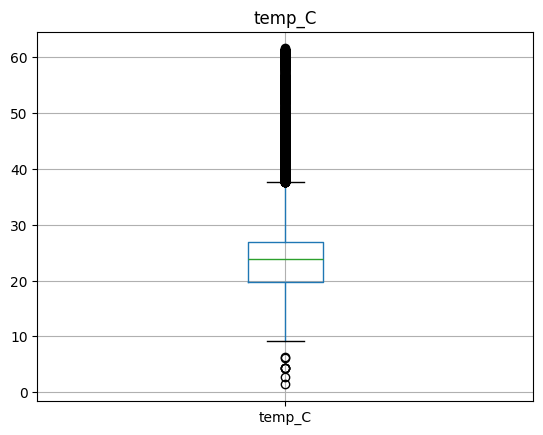

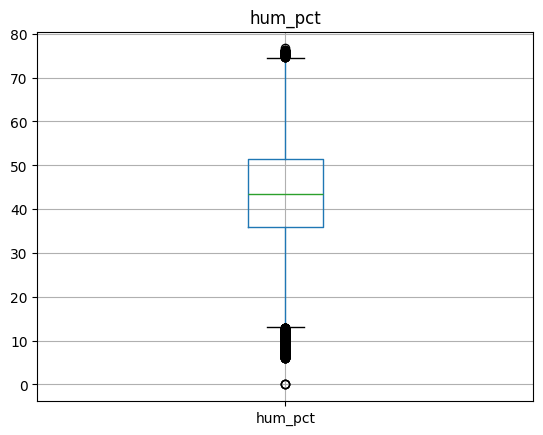

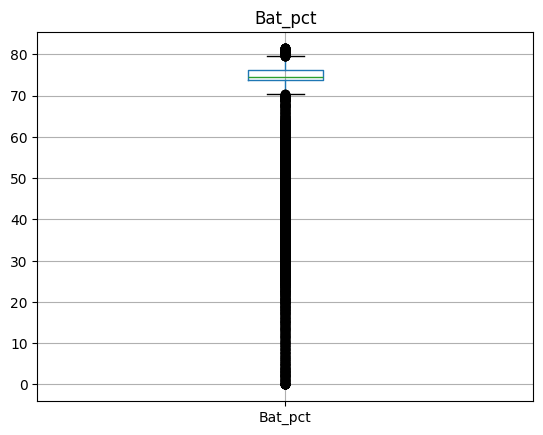

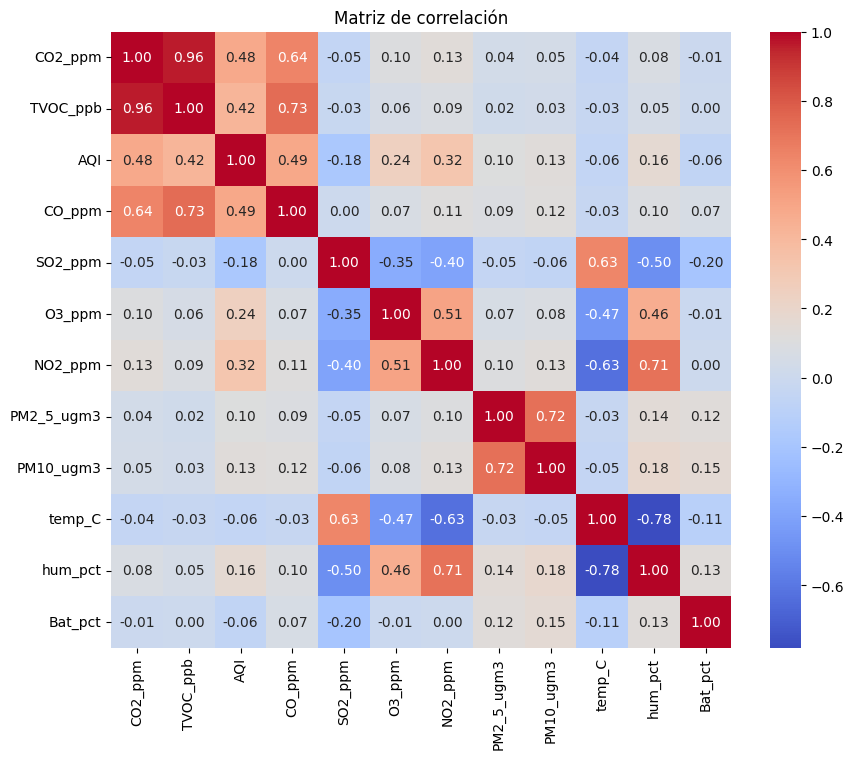

In [5]:
import matplotlib.pyplot as plt

# Histogramas
data[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

# Boxplots (outliers)
for col in num_cols:
    plt.figure()
    data.boxplot(column=col)
    plt.title(col)
    plt.show()

# Correlación
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

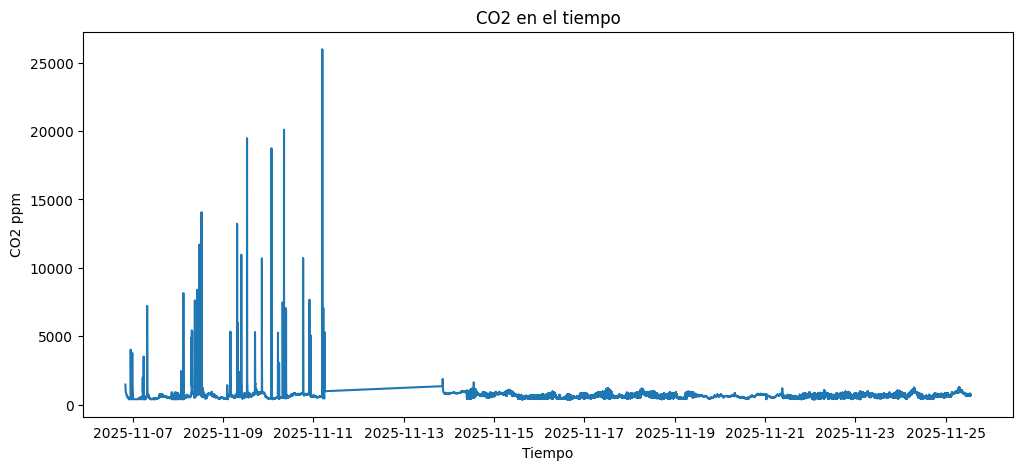

In [6]:
data['datetime'] = pd.to_datetime(data['datetime'])

data = data.sort_values('datetime')

# CO2
plt.figure(figsize=(12,5))
plt.plot(data['datetime'], data['CO2_ppm'])
plt.title("CO2 en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("CO2 ppm")
plt.show()

data['hour'] = data['datetime'].dt.hour
data['day'] = data['datetime'].dt.day
data['month'] = data['datetime'].dt.month

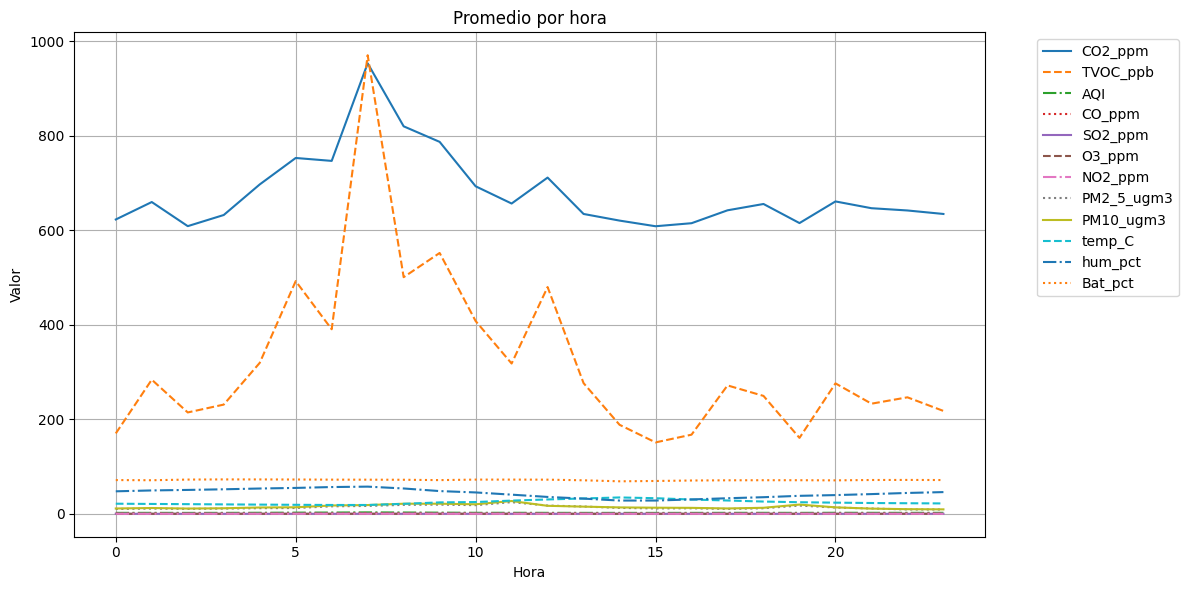

In [8]:
import itertools

hourly_avg = data.groupby('hour')[num_cols].mean()

linestyles = ['-', '--', '-.', ':']  # estilos distintos
style_cycle = itertools.cycle(linestyles)

plt.figure(figsize=(12,6))

for col, ls in zip(hourly_avg.columns, style_cycle):
    plt.plot(hourly_avg.index, hourly_avg[col], linestyle=ls, label=col)

plt.title("Promedio por hora")
plt.xlabel("Hora")
plt.ylabel("Valor")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.show()

In [9]:
cat_cols = data.select_dtypes(exclude=[np.number]).columns

for i in cat_cols:
    print()
    print(10*"=")
    print(f"{i}, {len(data[i])}, {data[i].nunique()}")
    print(10*"=")
    
    counts = data[i].value_counts(dropna=True)
    nan_count = data[i].isna().sum()
    
    for j in data[i].unique():
        count = nan_count if pd.isna(j) else counts.get(j, 0)
        print(f"({count})")
        print(j)
        print()
    
    print()
    print()


sensor_periodo, 28654, 4
(6208)
D_P1

(7550)
D_P2

(8343)
E_P2

(6553)
C_P2




datetime, 28654, 28476
(1)
2025-11-06 20:09:35

(1)
2025-11-06 20:10:18

(1)
2025-11-06 20:11:19

(1)
2025-11-06 20:12:19

(1)
2025-11-06 20:13:20

(1)
2025-11-06 20:14:20

(1)
2025-11-06 20:15:22

(1)
2025-11-06 20:16:22

(1)
2025-11-06 20:17:22

(1)
2025-11-06 20:18:44

(1)
2025-11-06 20:19:45

(1)
2025-11-06 20:20:46

(1)
2025-11-06 20:21:47

(1)
2025-11-06 20:22:47

(1)
2025-11-06 20:23:48

(1)
2025-11-06 20:24:48

(1)
2025-11-06 20:25:53

(1)
2025-11-06 20:26:55

(1)
2025-11-06 20:27:56

(1)
2025-11-06 20:28:57

(1)
2025-11-06 20:29:58

(1)
2025-11-06 20:31:00

(1)
2025-11-06 20:32:01

(1)
2025-11-06 20:33:01

(1)
2025-11-06 20:34:02

(1)
2025-11-06 20:35:03

(1)
2025-11-06 20:36:04

(1)
2025-11-06 20:37:05

(1)
2025-11-06 20:38:07

(1)
2025-11-06 20:39:08

(1)
2025-11-06 20:40:10

(1)
2025-11-06 20:41:11

(1)
2025-11-06 20:42:12

(1)
2025-11-06 20:43:14

(1)
2025-11-06 20:44:15

(1)
2025-11-06 20:45: